# Paper figures (size25 no_comms): architecture comparison across init scales

This notebook compares all **size-25, `no_comms`** variants across architectures:
- task-routed two-module
- shared two-module
- single-module baseline

It follows the paper-faithful metric definitions and uses uncertainty conventions with participant-level summaries (mean ± SEM).


In [1]:
# 1) Setup

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}

PHASE_ORDER = ["post_A", "post_B", "post_A2"]

# We keep the same global ordering conventions as the existing notebooks.
INIT_SCALE_ORDER = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 2]
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]

# Minimal paper grid
PAPER_INIT_SCALES = [0.001, 0.01, 0.1, 1.0, 2]
PAPER_SPARSITIES = ["no_comms", "0.5", "1.0"]

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.paper_single_baseline import (
    ROUTING_HUE_ORDER,
    ROUTING_PALETTE,
    broadcast_baseline_sparsity,
    select_single_baseline_df,
)
from a1b2.analysis.transfer_interference import prepare_pca_shared_three_phase
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2, get_axis_limits

sim_folder = (project_root / "data" / "simulations")
config_path = (project_root / "a1b2" / "models" / "experiments.json")
settings = json.loads(config_path.read_text())

sns.set_theme(context="notebook", style="whitegrid")

print("Project root:", project_root)
print("Simulations folder:", sim_folder)
print("Config:", config_path)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations
Config: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/experiments.json


In [2]:
# 2) Select size-25 no_comms runs across architecture groups

TARGET_TWO_MODULE_ARCH = "two_module_rnn"
TARGET_SINGLE_ARCH = "single_module_rnn"
TARGET_DIM_HIDDEN = 50
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False
PAPER_SPARSITIES = ["no_comms"]  # focused notebook


def sparsity_label_from_condition(c):
    sp = c.get("sparsity", 1.0)
    if sp == 0 or "no_comms" in c.get("name", ""):
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def init_scale_from_condition(c):
    init_scale = c.get("init_scale", None)
    return float(1.0 if init_scale is None else init_scale)


def _match_common_filters(c):
    if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
        return False
    if c.get("nb_steps", 1) != TARGET_NB_STEPS:
        return False
    if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
        return False
    if c.get("common_input", False) is not TARGET_COMMON_INPUT:
        return False
    return True


def select_two_module_conditions(input_routing: str):
    conds = []
    for c in settings["conditions"]:
        if c.get("arch") != TARGET_TWO_MODULE_ARCH:
            continue
        if not _match_common_filters(c):
            continue
        if c.get("input_routing", "shared") != input_routing:
            continue

        sp_label = sparsity_label_from_condition(c)
        init_scale = init_scale_from_condition(c)
        if sp_label not in PAPER_SPARSITIES:
            continue
        if init_scale not in PAPER_INIT_SCALES:
            continue

        run_id = build_run_id(c)
        path = sim_folder / run_id
        conds.append({
            **c,
            "run_id": run_id,
            "path": str(path),
            "path_exists": path.exists(),
            "sparsity_label": sp_label,
            "init_scale": init_scale,
        })

    df = pd.DataFrame(conds)
    if df.empty:
        return df
    df["sparsity_label"] = pd.Categorical(df["sparsity_label"], categories=SPARSITY_ORDER, ordered=True)
    return df.sort_values(["init_scale", "name"]).reset_index(drop=True)


task_df = select_two_module_conditions("task_routed")
shared_df = select_two_module_conditions("shared")

single_df = select_single_baseline_df(
    settings,
    sim_folder,
    two_module_dim_hidden=TARGET_DIM_HIDDEN,
    paper_sparsities=["1.0"],
    paper_init_scales=PAPER_INIT_SCALES,
    sparsity_order=SPARSITY_ORDER,
    build_run_id=build_run_id,
    sparsity_label_from_condition=sparsity_label_from_condition,
    init_scale_from_condition=init_scale_from_condition,
    target_nb_steps=TARGET_NB_STEPS,
    target_common_readout=TARGET_COMMON_READOUT,
    target_common_input=TARGET_COMMON_INPUT,
)

# Baseline selection is independent of the no_comms filter: use full-comms single-module (size-matched via helper), then map to this notebook's no_comms comparison facet.
if len(single_df):
    single_df = single_df.copy()
    single_df["sparsity_label"] = "no_comms"

print("Task-routed selected:", len(task_df), "valid:", int(task_df["path_exists"].sum()) if len(task_df) else 0)
print("Shared selected:", len(shared_df), "valid:", int(shared_df["path_exists"].sum()) if len(shared_df) else 0)
print("Single-module selected:", len(single_df), "valid:", int(single_df["path_exists"].sum()) if len(single_df) else 0)

if len(task_df):
    display(task_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])
if len(shared_df):
    display(shared_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])
if len(single_df):
    display(single_df[["name", "run_id", "init_scale", "sparsity_label", "path_exists"]])


Task-routed selected: 5 valid: 3
Shared selected: 5 valid: 2
Single-module selected: 0 valid: 0


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_50_task_routed_no_comms_nb2_ini...,two_module_rnn_50_task_routed_no_comms_nb2_ini...,0.001,no_comms,False
1,two_module_rnn_50_task_routed_no_comms_nb2_ini...,two_module_rnn_50_task_routed_no_comms_nb2_ini...,0.010,no_comms,True
2,two_module_rnn_50_task_routed_no_comms_nb2_ini...,two_module_rnn_50_task_routed_no_comms_nb2_ini...,0.100,no_comms,True
3,two_module_rnn_50_task_routed_no_comms_nb2,two_module_rnn_50_task_routed_no_comms_nb2_nb2...,1.000,no_comms,True
4,two_module_rnn_50_task_routed_no_comms_nb2_init2,two_module_rnn_50_task_routed_no_comms_nb2_ini...,2.000,no_comms,False


,name,run_id,init_scale,sparsity_label,path_exists
0,two_module_rnn_50_no_comms_nb2_init0.001,two_module_rnn_50_no_comms_nb2_init0.001_nb2_s...,0.001,no_comms,False
1,two_module_rnn_50_no_comms_nb2_init0.01,two_module_rnn_50_no_comms_nb2_init0.01_nb2_sh...,0.010,no_comms,True
2,two_module_rnn_50_no_comms_nb2_init0.1,two_module_rnn_50_no_comms_nb2_init0.1_nb2_sha...,0.100,no_comms,False
3,two_module_rnn_50_no_comms_nb2,two_module_rnn_50_no_comms_nb2_nb2_shared_sp0_...,1.000,no_comms,True
4,two_module_rnn_50_no_comms_nb2_init2,two_module_rnn_50_no_comms_nb2_init2_nb2_share...,2.000,no_comms,False


In [3]:
# 3) Load ANN data + build participant-level dataframes (transfer, phase accuracies, rep metrics, angles)

from collections import defaultdict


def load_all_ann_data(df_runs: pd.DataFrame):
    out = {}
    for _, row in df_runs[df_runs["path_exists"]].iterrows():
        run_id = row["run_id"]
        path = Path(row["path"])
        ann_data = ann.load_ann_data(path)
        out[run_id] = {
            "data": ann_data,
            "init_scale": float(row["init_scale"]),
            "sparsity_label": str(row["sparsity_label"]),
        }
    return out


def compute_metrics(all_ann_data: dict):
    transfer_records = []
    accuracy_records = []
    rep_records = []
    angles_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]

        # principal angles (A vs B)
        angles_df = ann.get_principal_angles(ann_data)
        angles_df = angles_df.copy()
        angles_df["run_id"] = run_id
        angles_df["init_scale"] = init_scale
        angles_df["sparsity_label"] = sp_label
        angles_records.append(angles_df)

        # participant-level metrics
        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))

                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                # Transfer (error_diff): init_B - final_A1
                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        final_A1 = float(np.mean(A1_acc[-6:]))
                        init_B = float(np.mean(B_acc[:6]))
                        transfer_records.append(
                            {
                                "run_id": run_id,
                                "init_scale": init_scale,
                                "sparsity_label": sp_label,
                                "condition": cond_name,
                                "participant": pid,
                                "error_diff": init_B - final_A1,
                            }
                        )

                # Phase accuracies
                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = PHASE_ORDER[ph]
                    accuracy_records.append(
                        {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                        }
                    )

                # Representation metrics (combined/core/comms) per phase
                for phase_idx, phase_name in enumerate(PHASE_ORDER):
                    if f"hiddens_post_phase_{phase_idx}" not in entry:
                        continue
                    for path in ("combined", "core", "comms"):
                        try:
                            hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                        except Exception:
                            continue
                        metrics = ann.compute_state_representation_metrics(
                            hids, variance_thresholds=(0.95, 0.99), top_k=2
                        )
                        row = {
                            "run_id": run_id,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "pathway": path,
                            "var_topk": float(metrics["var_topk"]),
                        }
                        for thr, n in metrics["n_components"].items():
                            row[f"n_pcs_{int(thr*100)}"] = int(n)
                        rep_records.append(row)

    transfer_df = pd.DataFrame(transfer_records)
    acc_df = pd.DataFrame(accuracy_records)
    rep_df = pd.DataFrame(rep_records)
    angles_all = pd.concat(angles_records, ignore_index=True) if angles_records else pd.DataFrame()

    return transfer_df, acc_df, rep_df, angles_all


all_task = load_all_ann_data(task_df)
all_shared = load_all_ann_data(shared_df)

transfer_task, acc_task, rep_task, angles_task = compute_metrics(all_task)
transfer_shared, acc_shared, rep_shared, angles_shared = compute_metrics(all_shared)
all_single = load_all_ann_data(single_df) if len(single_df) else {}
transfer_single, acc_single, rep_single, angles_single = compute_metrics(all_single)

print("task: transfer", transfer_task.shape, "acc", acc_task.shape, "rep", rep_task.shape, "angles", angles_task.shape)
print("shared: transfer", transfer_shared.shape, "acc", acc_shared.shape, "rep", rep_shared.shape, "angles", angles_shared.shape)
print(
    "single: transfer",
    transfer_single.shape,
    "acc",
    acc_single.shape,
    "rep",
    rep_single.shape,
    "angles",
    angles_single.shape,
)


task: transfer (915, 6) acc (2745, 7) rep (2745, 10) angles (915, 6)
shared: transfer (610, 6) acc (1830, 7) rep (1830, 10) angles (610, 6)
single: transfer (0, 0) acc (0, 0) rep (0, 0) angles (0, 0)


## Coverage diagnostics

Run and participant coverage by architecture group × init scale × similarity.


In [4]:
def add_architecture_group(df: pd.DataFrame, group: str):
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out["architecture_group"] = group
    return out

run_cov_parts = []
for group, df in [
    ("task_routed", task_df),
    ("shared", shared_df),
    ("single_module", single_df),
]:
    if df is None or df.empty:
        continue
    tmp = df.copy()
    tmp["architecture_group"] = group
    run_cov_parts.append(tmp[["architecture_group", "init_scale", "run_id", "path_exists"]])

if run_cov_parts:
    run_cov = pd.concat(run_cov_parts, ignore_index=True)
    run_cov_tbl = (
        run_cov.groupby(["architecture_group", "init_scale"], observed=True)
        .agg(selected_runs=("run_id", "nunique"), valid_runs=("path_exists", "sum"))
        .reset_index()
        .sort_values(["architecture_group", "init_scale"])
    )
    display(run_cov_tbl)

transfer_all_arch = pd.concat([
    add_architecture_group(transfer_task, "task_routed"),
    add_architecture_group(transfer_shared, "shared"),
    add_architecture_group(transfer_single, "single_module"),
], ignore_index=True)

if not transfer_all_arch.empty:
    part_cov = (
        transfer_all_arch.groupby(["architecture_group", "init_scale", "condition"], observed=True)["participant"]
        .nunique()
        .reset_index(name="n_participants")
        .sort_values(["architecture_group", "init_scale", "condition"])
    )
    display(part_cov)


,architecture_group,init_scale,selected_runs,valid_runs
0,shared,0.001,1,0
1,shared,0.010,1,1
2,shared,0.100,1,0
3,shared,1.000,1,1
4,shared,2.000,1,0
5,task_routed,0.001,1,0
6,task_routed,0.010,1,1
7,task_routed,0.100,1,1
8,task_routed,1.000,1,1
9,task_routed,2.000,1,0


,architecture_group,init_scale,condition,n_participants
0,shared,0.01,far,101
1,shared,0.01,near,101
2,shared,0.01,same,103
3,shared,1.00,far,101
4,shared,1.00,near,101
5,shared,1.00,same,103
6,task_routed,0.01,far,101
7,task_routed,0.01,near,101
8,task_routed,0.01,same,103
9,task_routed,0.10,far,101


## Quantitative architecture comparison (no_comms)

All plots include task-routed, shared, and single-module baselines.


/tmp/ipykernel_530813/440872928.py:10: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_530813/440872928.py:10: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_530813/440872928.py:10: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


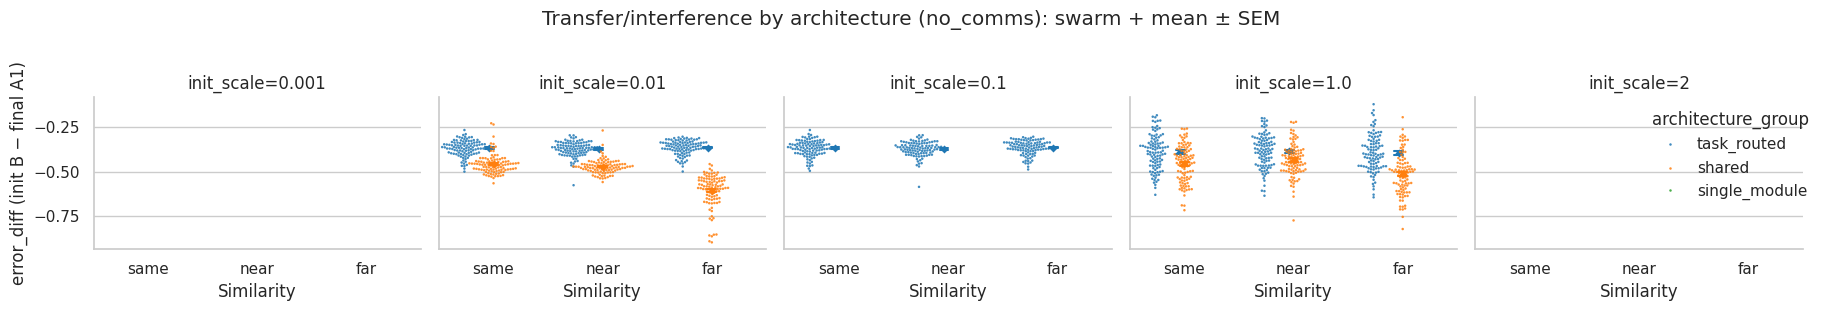

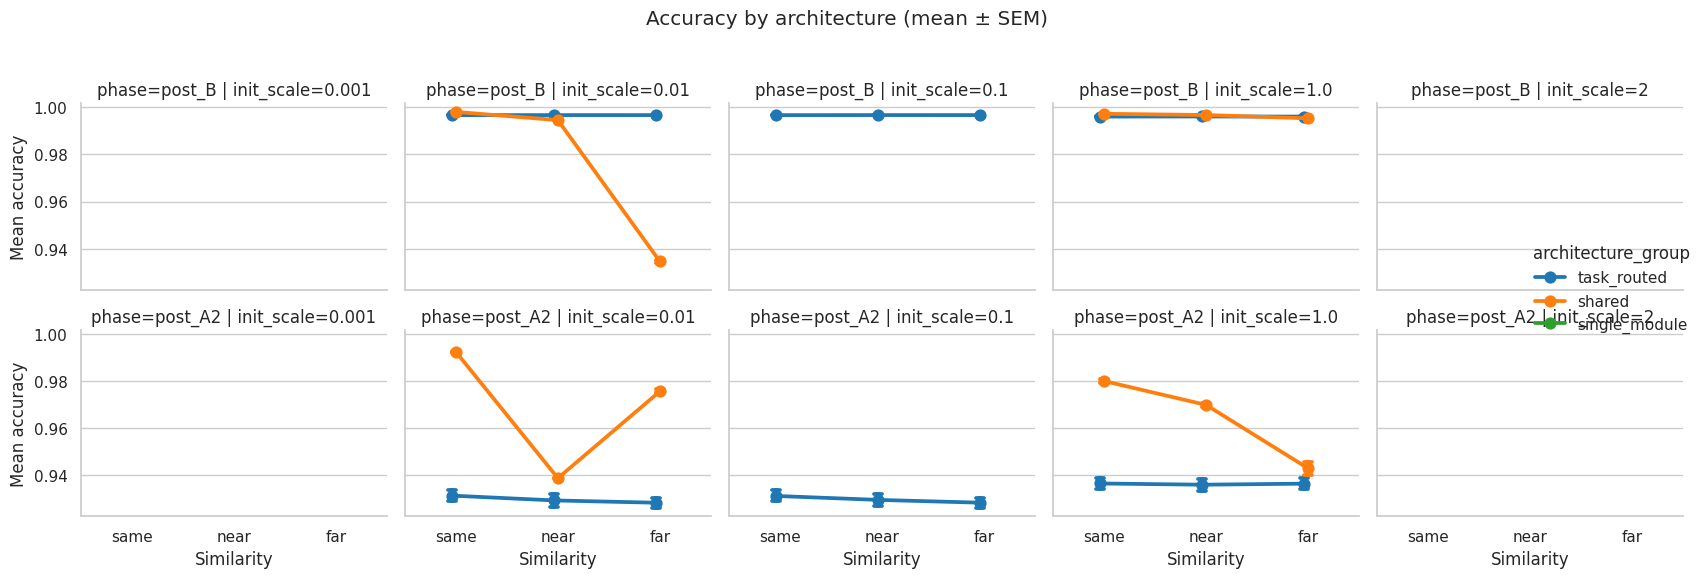

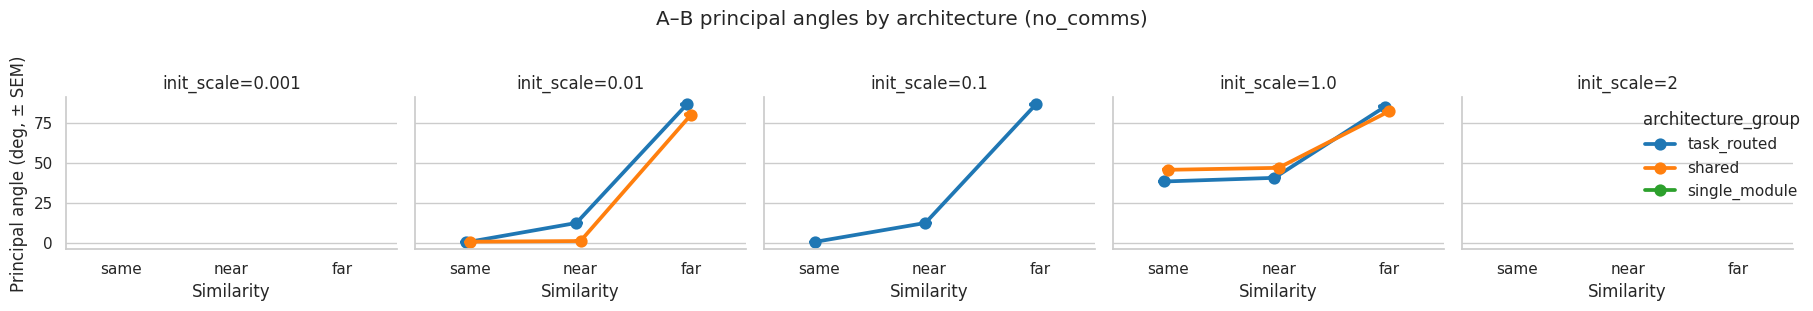

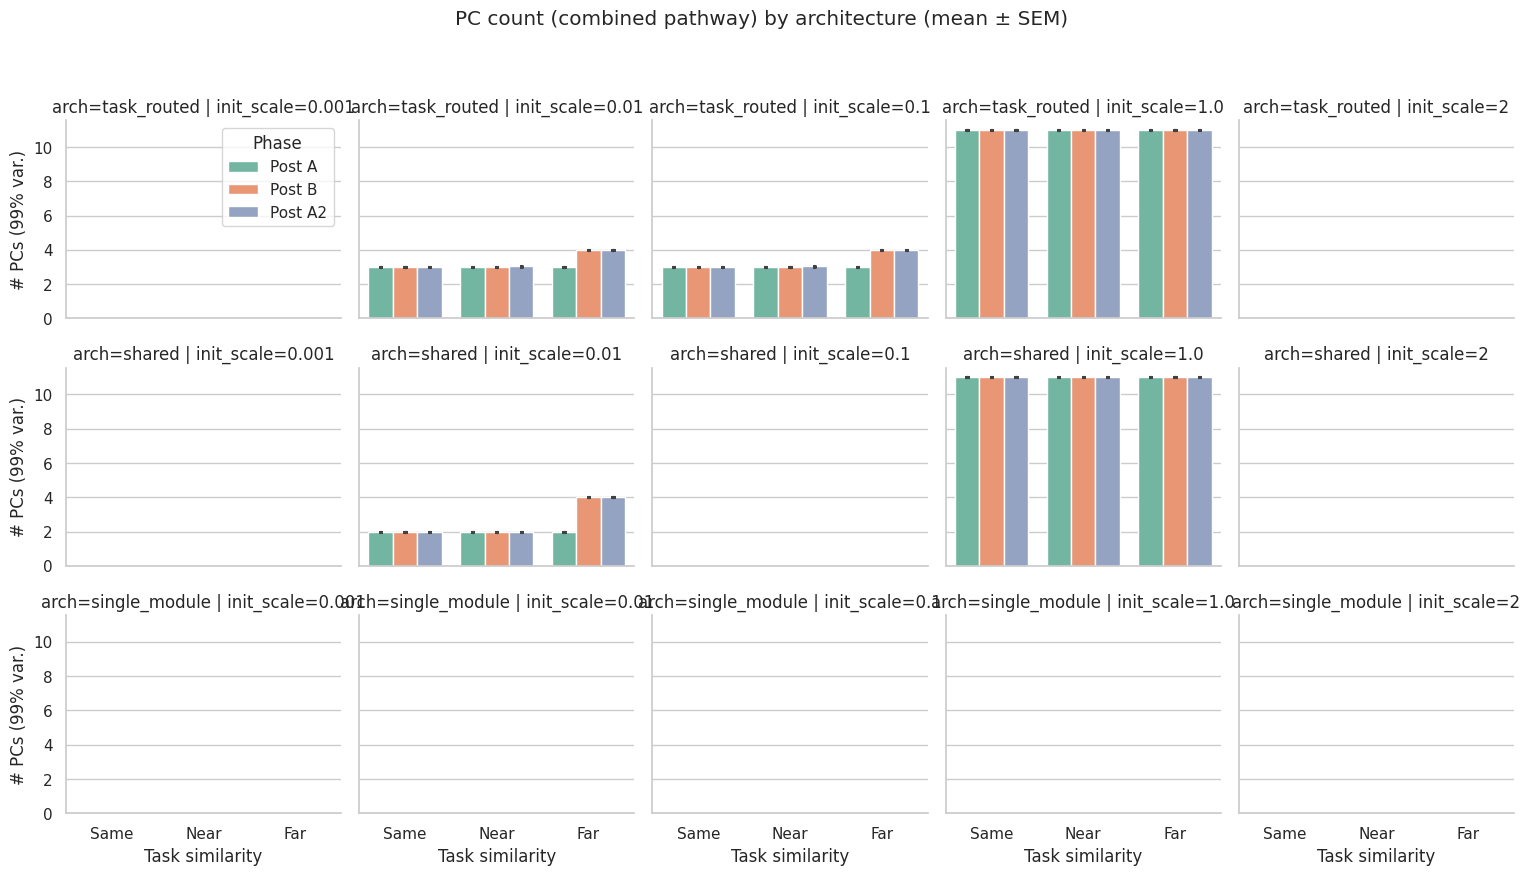

In [5]:
init_order = [s for s in PAPER_INIT_SCALES if s in INIT_SCALE_ORDER]


def _overlay_means_sem_per_init(g, df, ycol, hue_col, hue_order, palette, dodge=True, marker_scale=0.6):
    for j, init_scale in enumerate(init_order):
        ax = g.axes[0, j] if g.axes.ndim == 2 else g.axes[j]
        sub = df[df["init_scale"] == init_scale]
        if sub.empty:
            continue
        sns.pointplot(
            data=sub,
            x="condition",
            y=ycol,
            hue=hue_col,
            order=SIMILARITY_ORDER,
            hue_order=hue_order,
            palette=palette,
            dodge=dodge,
            ax=ax,
            errorbar="se",
            capsize=0.08,
            markers="D",
            linestyles="",
            scale=marker_scale,
            legend=False,
        )


# Transfer: swarm + mean ± SEM
tr_all = pd.concat([
    add_architecture_group(transfer_task, "task_routed"),
    add_architecture_group(transfer_shared, "shared"),
    add_architecture_group(transfer_single, "single_module"),
], ignore_index=True)

if not tr_all.empty:
    tr_all["init_scale"] = tr_all["init_scale"].astype(float)
    g = sns.catplot(
        data=tr_all,
        x="condition",
        y="error_diff",
        hue="architecture_group",
        col="init_scale",
        col_order=init_order,
        kind="swarm",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        size=1.8,
        linewidth=0,
        alpha=0.85,
        height=3.0,
        aspect=1.1,
    )
    _overlay_means_sem_per_init(g, tr_all, "error_diff", "architecture_group", ROUTING_HUE_ORDER, ROUTING_PALETTE, dodge=True, marker_scale=0.55)
    g.set_axis_labels("Similarity", "error_diff (init B − final A1)")
    g.set_titles(col_template="init_scale={col_name}")
    g.fig.suptitle("Transfer/interference by architecture (no_comms): swarm + mean ± SEM", y=1.03)
    plt.tight_layout()
    plt.show()

# Accuracy: pointplot mean ± SEM
acc_all = pd.concat([
    add_architecture_group(acc_task, "task_routed"),
    add_architecture_group(acc_shared, "shared"),
    add_architecture_group(acc_single, "single_module"),
], ignore_index=True)

if not acc_all.empty:
    sub = acc_all[acc_all["phase"].isin(["post_B", "post_A2"])].copy()
    sub["init_scale"] = sub["init_scale"].astype(float)
    g = sns.catplot(
        data=sub,
        x="condition",
        y="mean_accuracy",
        hue="architecture_group",
        col="init_scale",
        row="phase",
        col_order=init_order,
        row_order=["post_B", "post_A2"],
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=2.8,
        aspect=1.1,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Mean accuracy")
    g.set_titles(row_template="phase={row_name}", col_template="init_scale={col_name}")
    g.fig.suptitle("Accuracy by architecture (mean ± SEM)", y=1.03)
    plt.tight_layout()
    plt.show()

# Angles: participant-level pointplot ± SEM
ang_all = pd.concat([
    add_architecture_group(angles_task, "task_routed"),
    add_architecture_group(angles_shared, "shared"),
    add_architecture_group(angles_single, "single_module"),
], ignore_index=True)

if not ang_all.empty:
    ang_all["init_scale"] = ang_all["init_scale"].astype(float)
    g = sns.catplot(
        data=ang_all,
        x="condition",
        y="principal_angle_between",
        hue="architecture_group",
        col="init_scale",
        col_order=init_order,
        kind="point",
        dodge=True,
        order=SIMILARITY_ORDER,
        hue_order=ROUTING_HUE_ORDER,
        palette=ROUTING_PALETTE,
        height=3.0,
        aspect=1.1,
        errorbar="se",
        capsize=0.08,
    )
    g.set_axis_labels("Similarity", "Principal angle (deg, ± SEM)")
    g.set_titles(col_template="init_scale={col_name}")
    g.fig.suptitle("A–B principal angles by architecture (no_comms)", y=1.03)
    plt.tight_layout()
    plt.show()

# PC count: participant-level bars ± SEM
rep_all = pd.concat([
    add_architecture_group(rep_task, "task_routed"),
    add_architecture_group(rep_shared, "shared"),
    add_architecture_group(rep_single, "single_module"),
], ignore_index=True)

if not rep_all.empty:
    pc = rep_all[(rep_all["pathway"] == "combined")].copy()
    pc["init_scale"] = pc["init_scale"].astype(float)
    pc["phase"] = pd.Categorical(pc["phase"], categories=PHASE_ORDER, ordered=True)
    pc["condition"] = pd.Categorical(pc["condition"], categories=SIMILARITY_ORDER, ordered=True)
    if "n_pcs_99" in pc.columns and not pc.empty:
        phase_labels = {"post_A": "Post A", "post_B": "Post B", "post_A2": "Post A2"}
        cond_labels = {"same": "Same", "near": "Near", "far": "Far"}
        pc["phase_plot"] = pc["phase"].map(phase_labels)
        pc["condition_plot"] = pc["condition"].map(cond_labels)
        g = sns.catplot(
            data=pc,
            x="condition_plot",
            y="n_pcs_99",
            hue="phase_plot",
            col="init_scale",
            row="architecture_group",
            col_order=init_order,
            row_order=ROUTING_HUE_ORDER,
            kind="bar",
            order=["Same", "Near", "Far"],
            hue_order=["Post A", "Post B", "Post A2"],
            palette="Set2",
            height=2.8,
            aspect=1.1,
            legend_out=False,
            errorbar="se",
            capsize=0.04,
        )
        g.set_axis_labels("Task similarity", "# PCs (99% var.)")
        g.set_titles(row_template="arch={row_name}", col_template="init_scale={col_name}")
        if g._legend is not None:
            g._legend.set_title("Phase")
        g.fig.suptitle("PC count (combined pathway) by architecture (mean ± SEM)", y=1.04)
        plt.tight_layout()
        plt.show()


## 2D PCA geometry by init scale (architecture rows × similarity columns)

For each init scale, one figure with rows = architecture and columns = same/near/far.


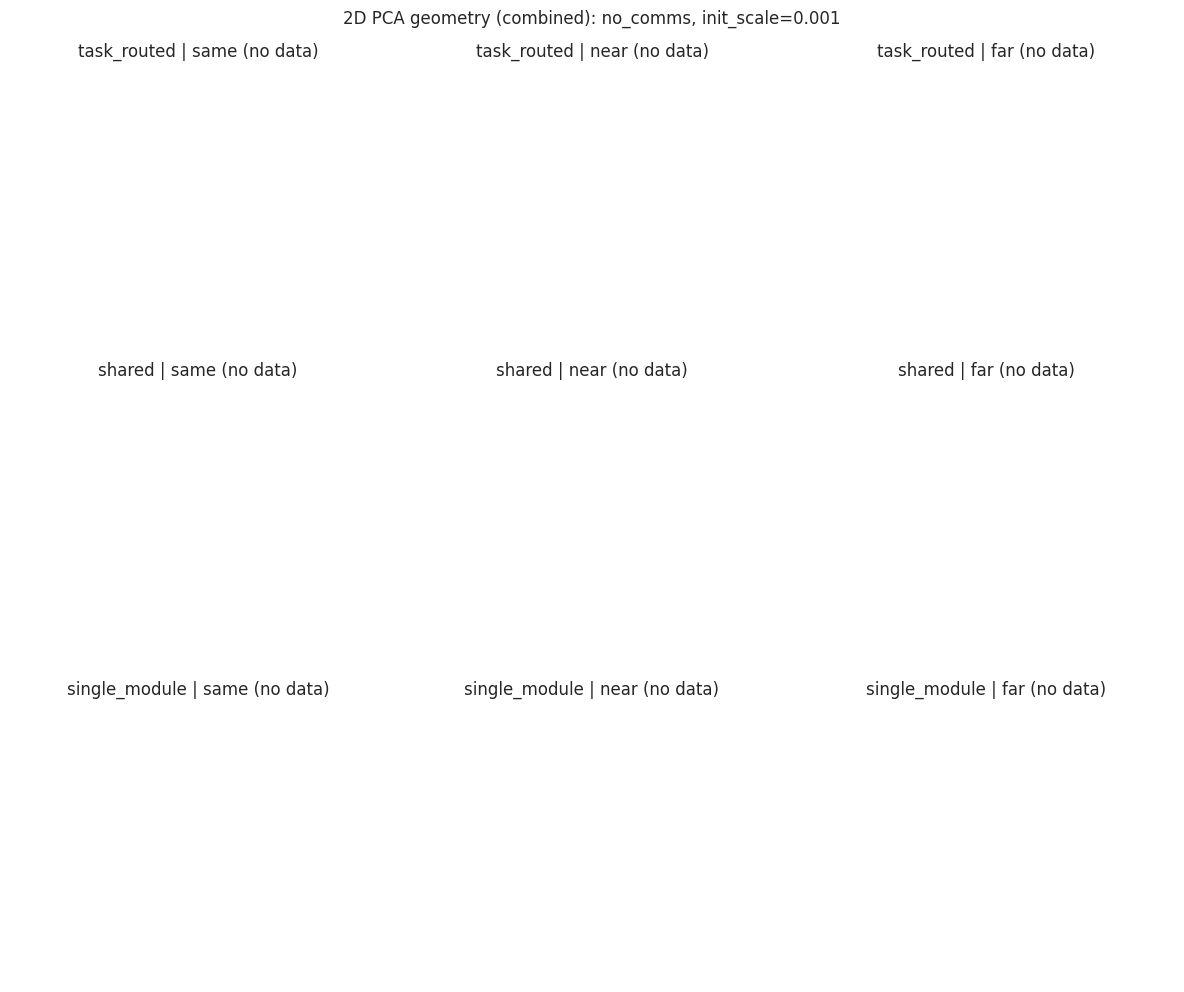

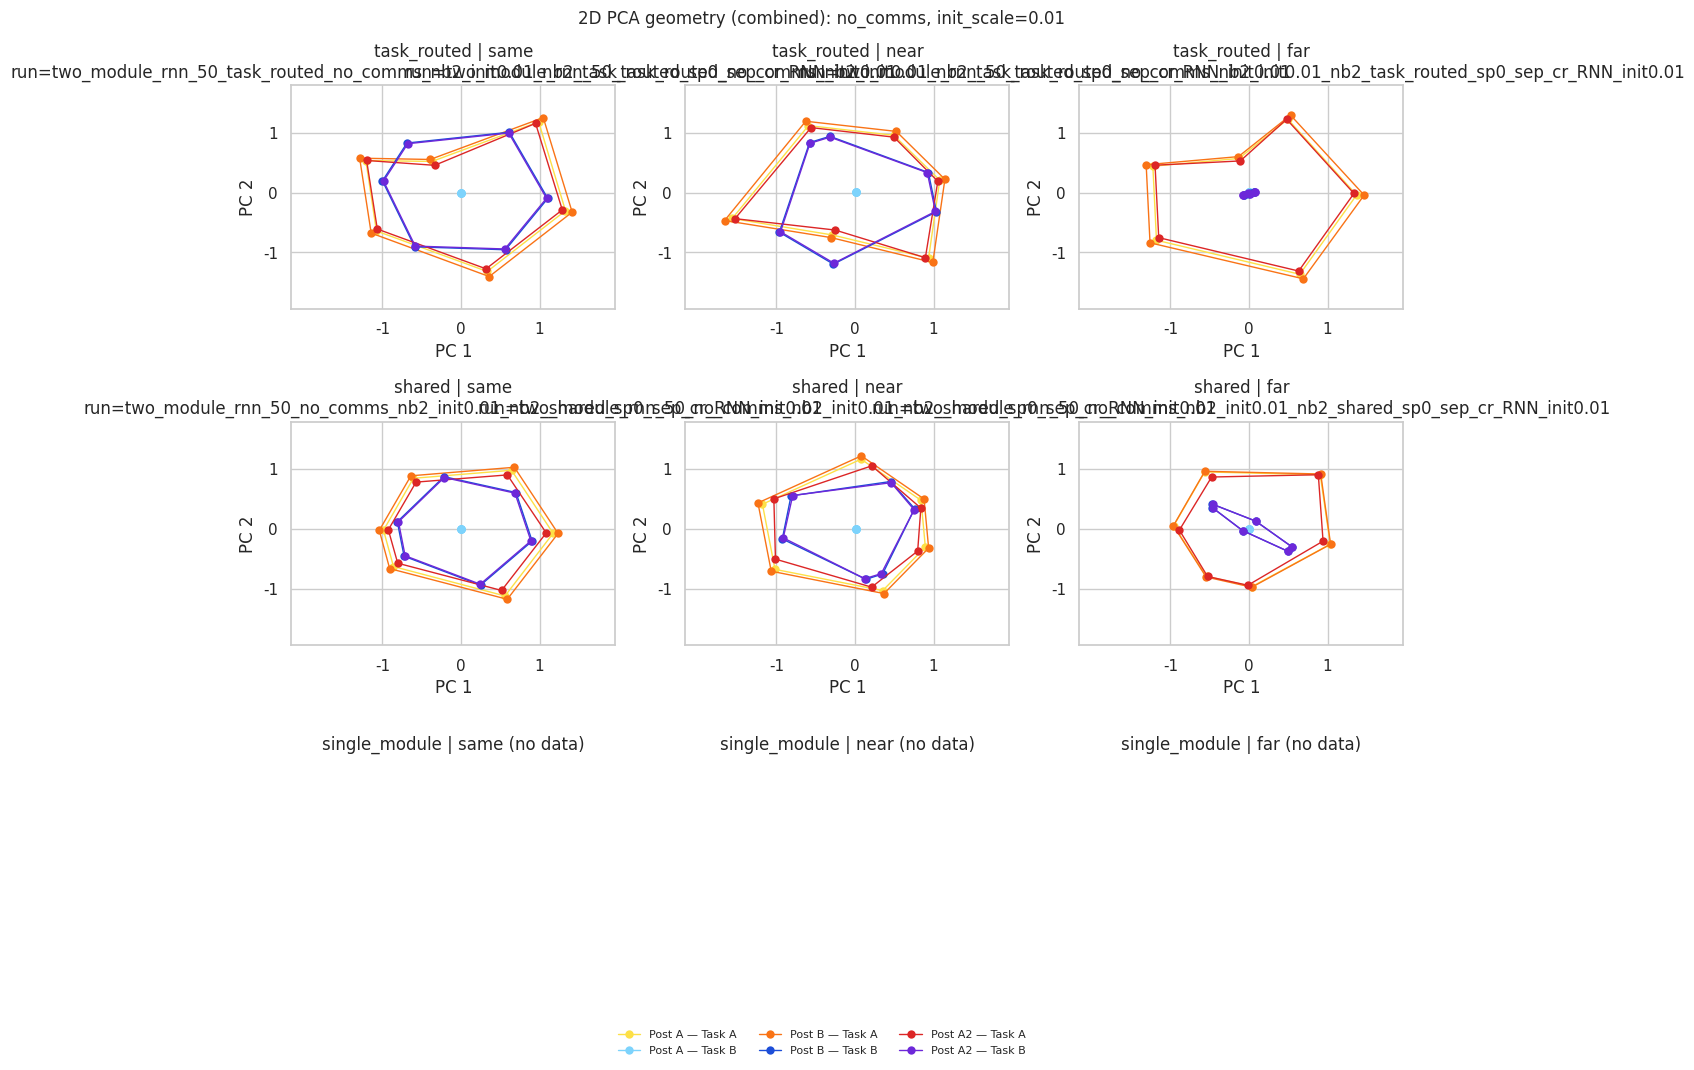

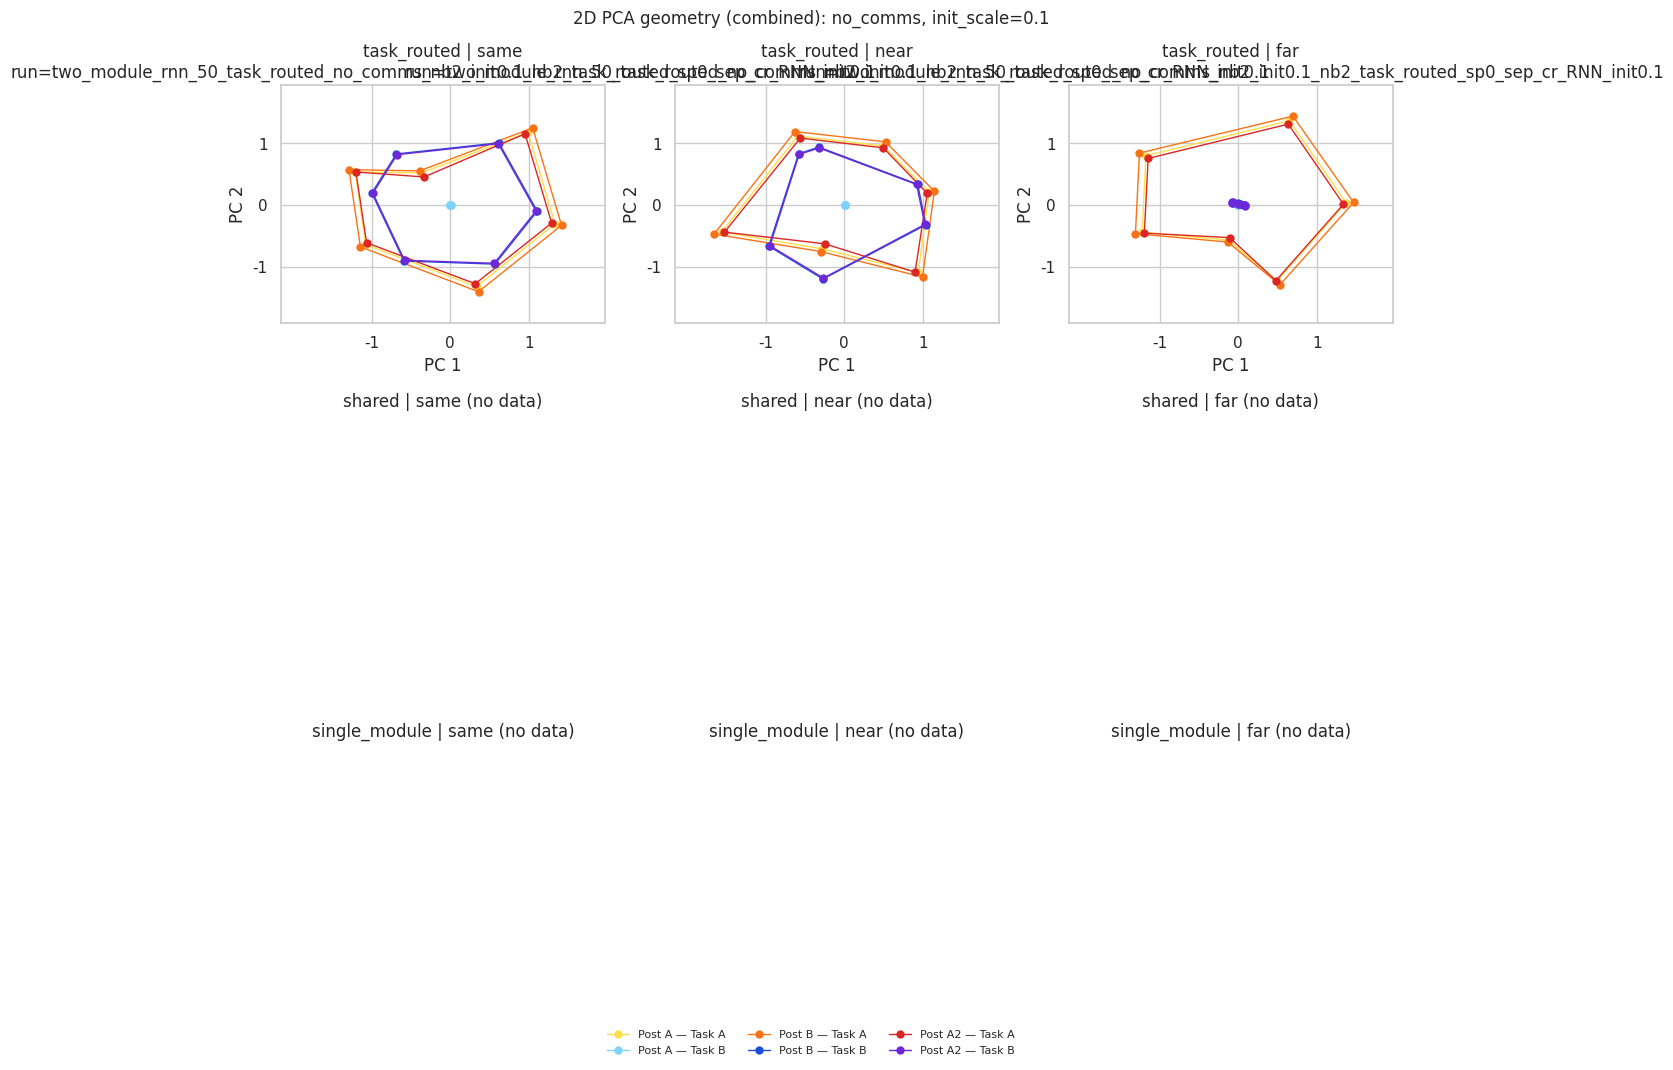

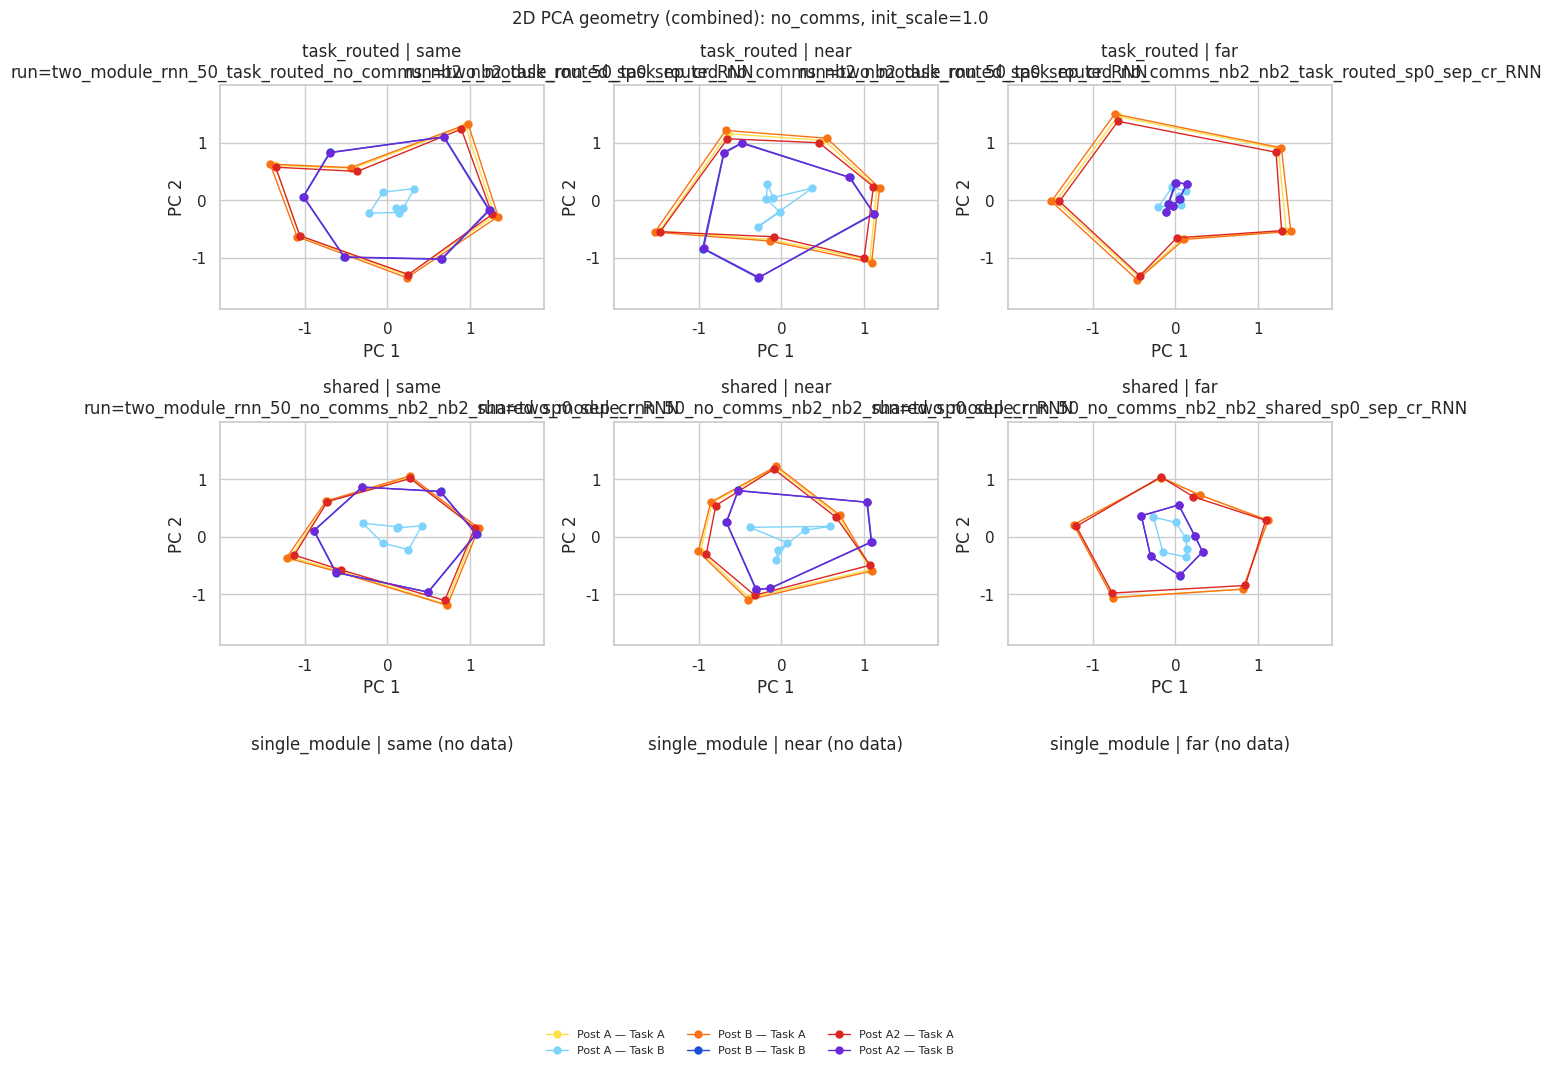

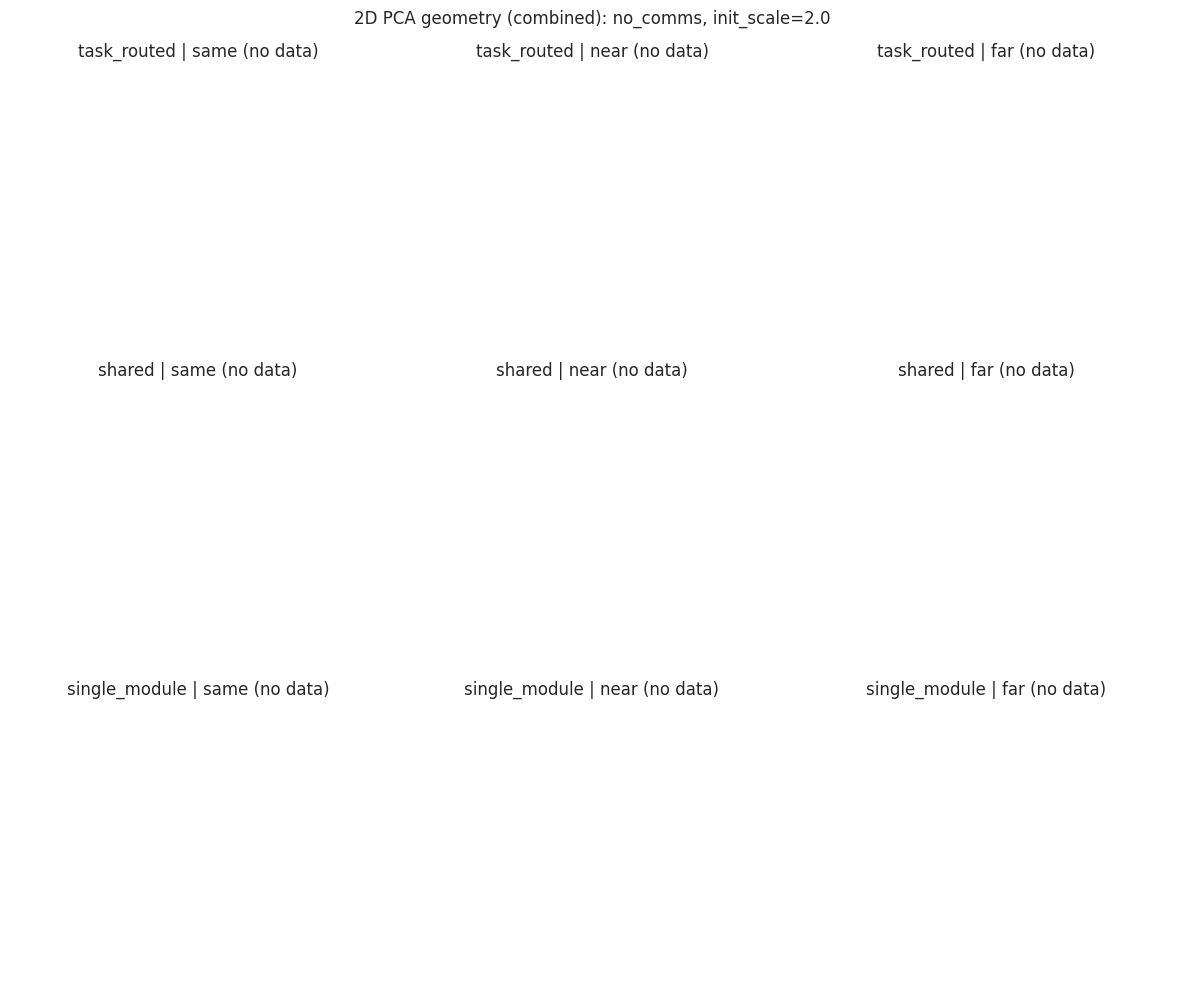

In [6]:
def _first_entry_for_condition(ann_data, cond_name):
    entries = ann_data.get(cond_name, [])
    return entries[0] if entries else None


def _get_arch_bundle(all_arch_data: dict, target_init: float):
    candidates = [
        (rid, b) for rid, b in all_arch_data.items()
        if str(b["sparsity_label"]) == "no_comms" and float(b["init_scale"]) == float(target_init)
    ]
    if not candidates:
        return None, None
    return candidates[0]


def plot_geometry_grid_2d_by_init(init_scale: float, n_stim_plot: int = 12):
    arch_map = {
        "task_routed": all_task,
        "shared": all_shared,
        "single_module": all_single,
    }
    conds = SIMILARITY_ORDER

    fig, axes = plt.subplots(3, 3, figsize=(12, 11))
    fig.suptitle(f"2D PCA geometry (combined): no_comms, init_scale={init_scale}", fontsize=12)

    # compute global limits across all available subplots
    triples = {}
    flat = []
    for arch_i, arch in enumerate(ROUTING_HUE_ORDER):
        rid, bundle = _get_arch_bundle(arch_map.get(arch, {}), init_scale)
        for cond in conds:
            key = (arch, cond)
            triples[key] = None
            if bundle is None:
                continue
            ann_data = bundle["data"]
            entry = _first_entry_for_condition(ann_data, cond)
            if entry is None:
                continue
            raw_A = entry.get("hiddens_post_phase_0")
            raw_B = entry.get("hiddens_post_phase_1")
            raw_A2 = entry.get("hiddens_post_phase_2")
            if raw_A is None or raw_B is None or raw_A2 is None:
                continue
            h_A = np.asarray(raw_A)
            h_B = np.asarray(raw_B)
            h_A2 = np.asarray(raw_A2)
            if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
                continue
            if min(h_A.shape[0], h_B.shape[0], h_A2.shape[0]) < n_stim_plot:
                continue
            h_A = h_A[:n_stim_plot]
            h_B = h_B[:n_stim_plot]
            h_A2 = h_A2[:n_stim_plot]
            _, X2_A, X2_B, X2_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=2)
            triples[key] = (X2_A, X2_B, X2_A2, rid)
            flat.extend([X2_A, X2_B, X2_A2])

    lims_global = get_axis_limits(np.vstack(flat)) if flat else {}

    for i, arch in enumerate(ROUTING_HUE_ORDER):
        for j, cond in enumerate(conds):
            ax = axes[i, j]
            triple = triples.get((arch, cond))
            if triple is None:
                ax.set_title(f"{arch} | {cond} (no data)")
                ax.axis("off")
                continue
            X2_A, X2_B, X2_A2, rid = triple
            plot_split_stim_postA_postB_postA2(ax, X2_A, X2_B, X2_A2, lims_global)
            ax.set_title(f"{arch} | {cond}\nrun={rid}")

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    # single shared legend
    for ax in axes.flat:
        hs, ls = ax.get_legend_handles_labels()
        if hs:
            fig.legend(hs, ls, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False, fontsize=8)
            break
    plt.show()


for init_scale in init_order:
    plot_geometry_grid_2d_by_init(float(init_scale), n_stim_plot=12)


## Appendix: 3D PCA geometry by init scale (architecture rows × similarity columns)


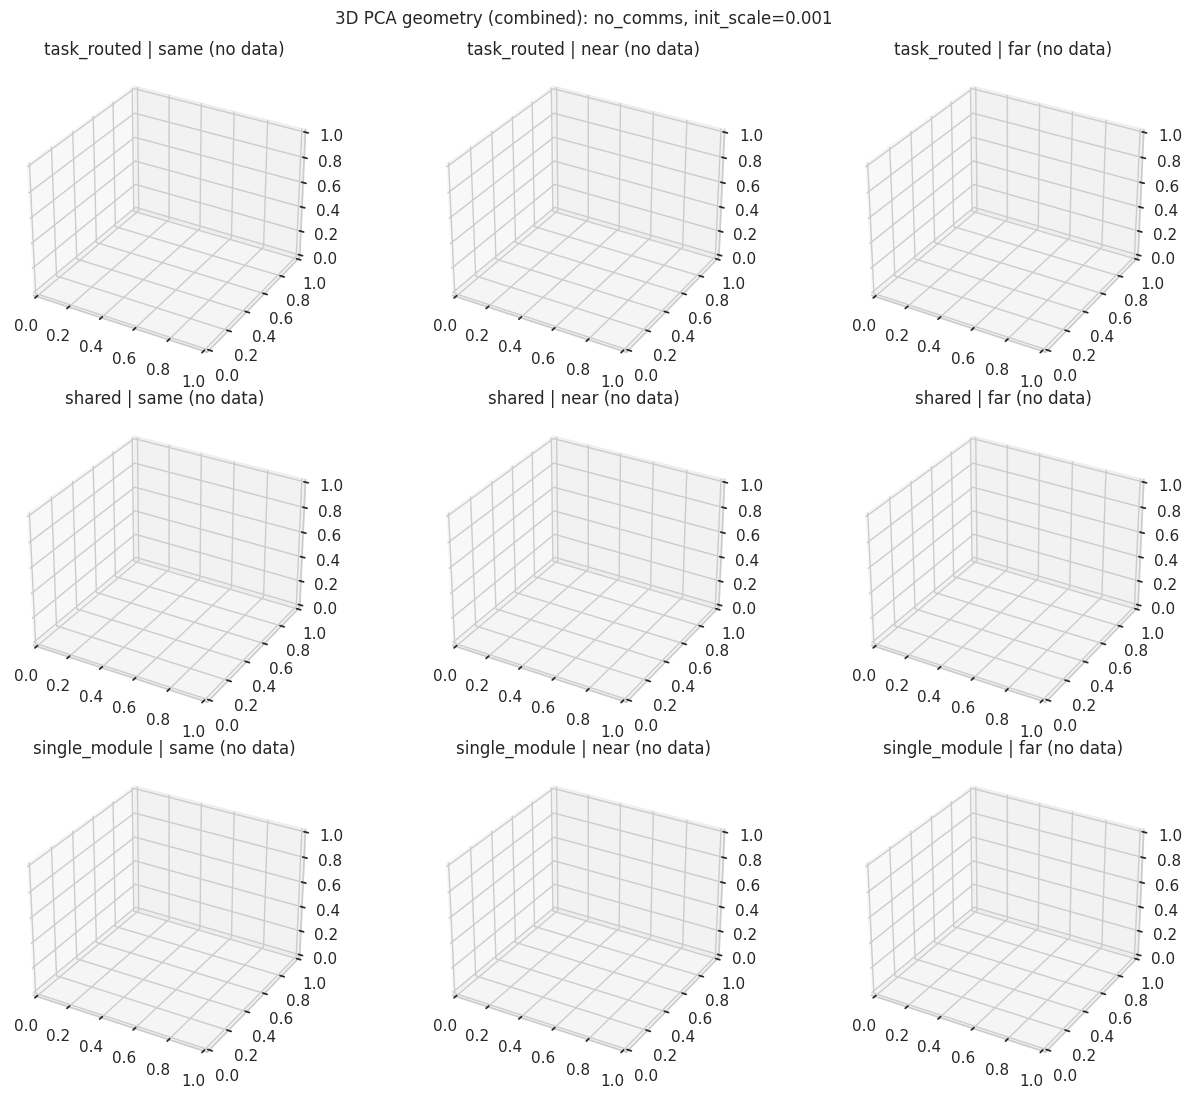

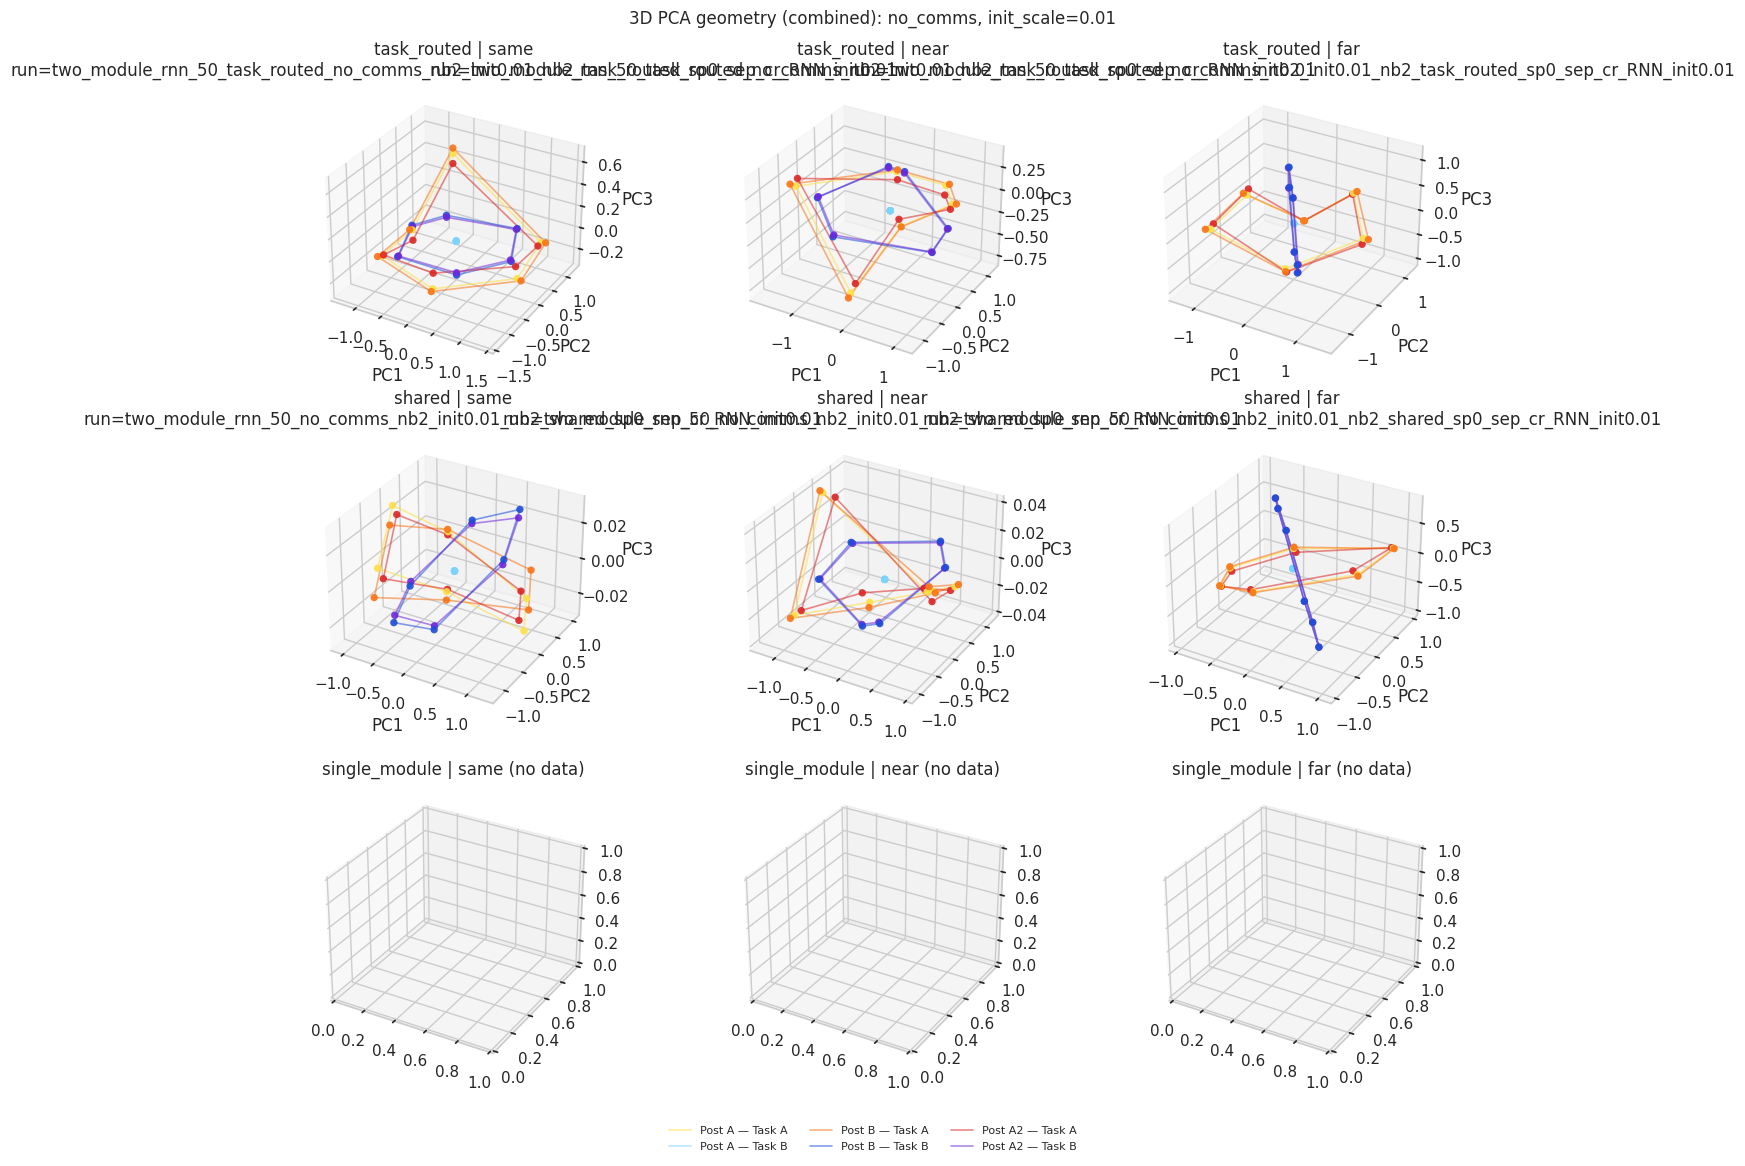

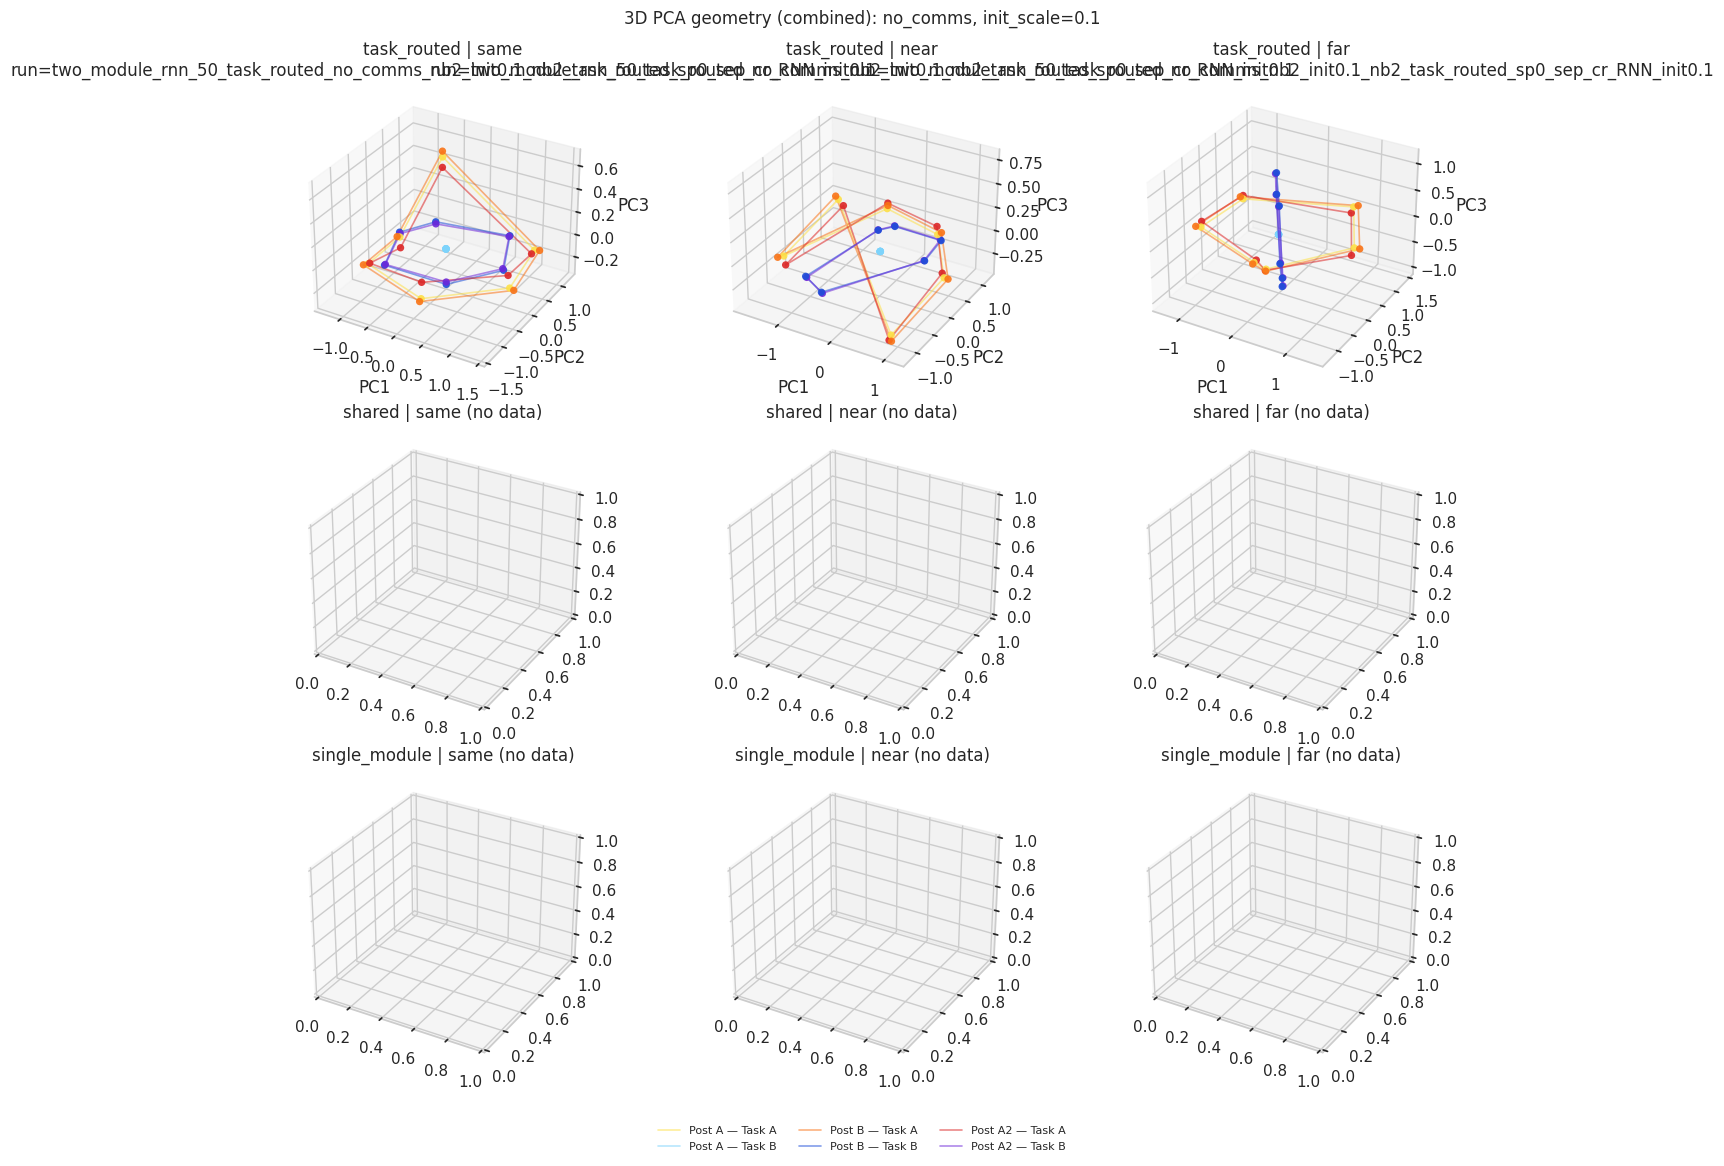

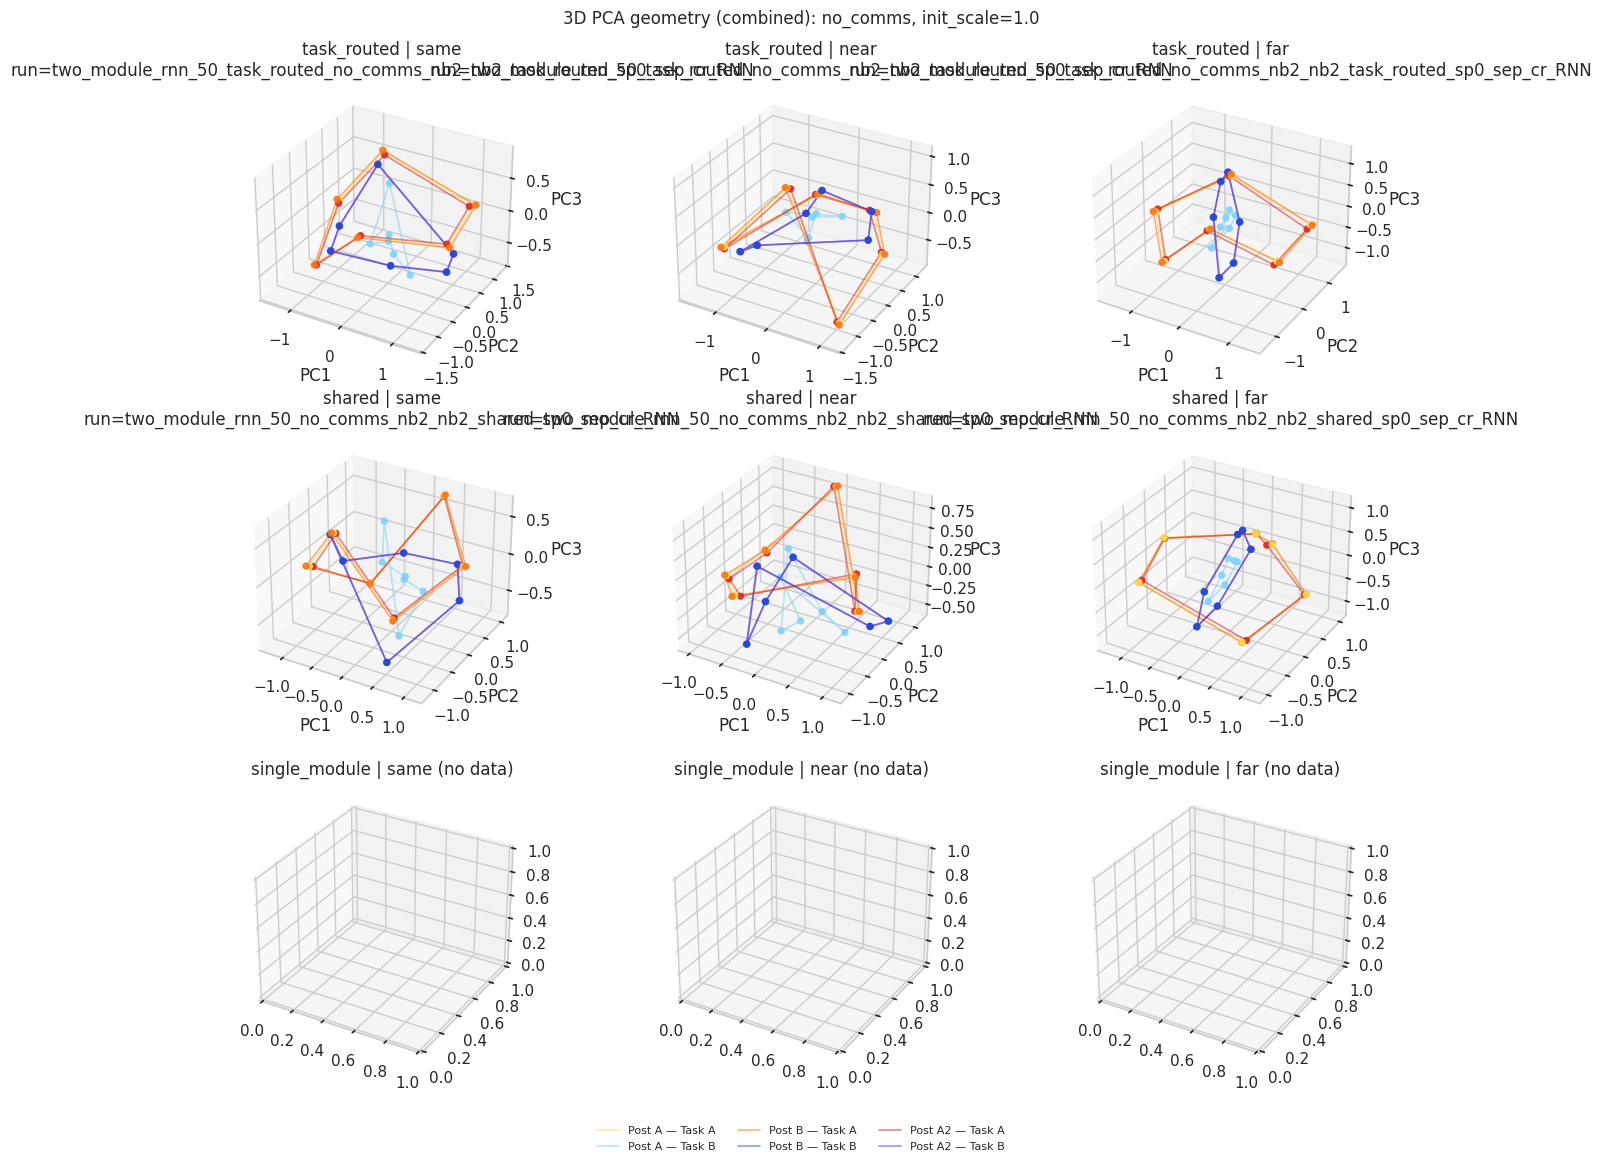

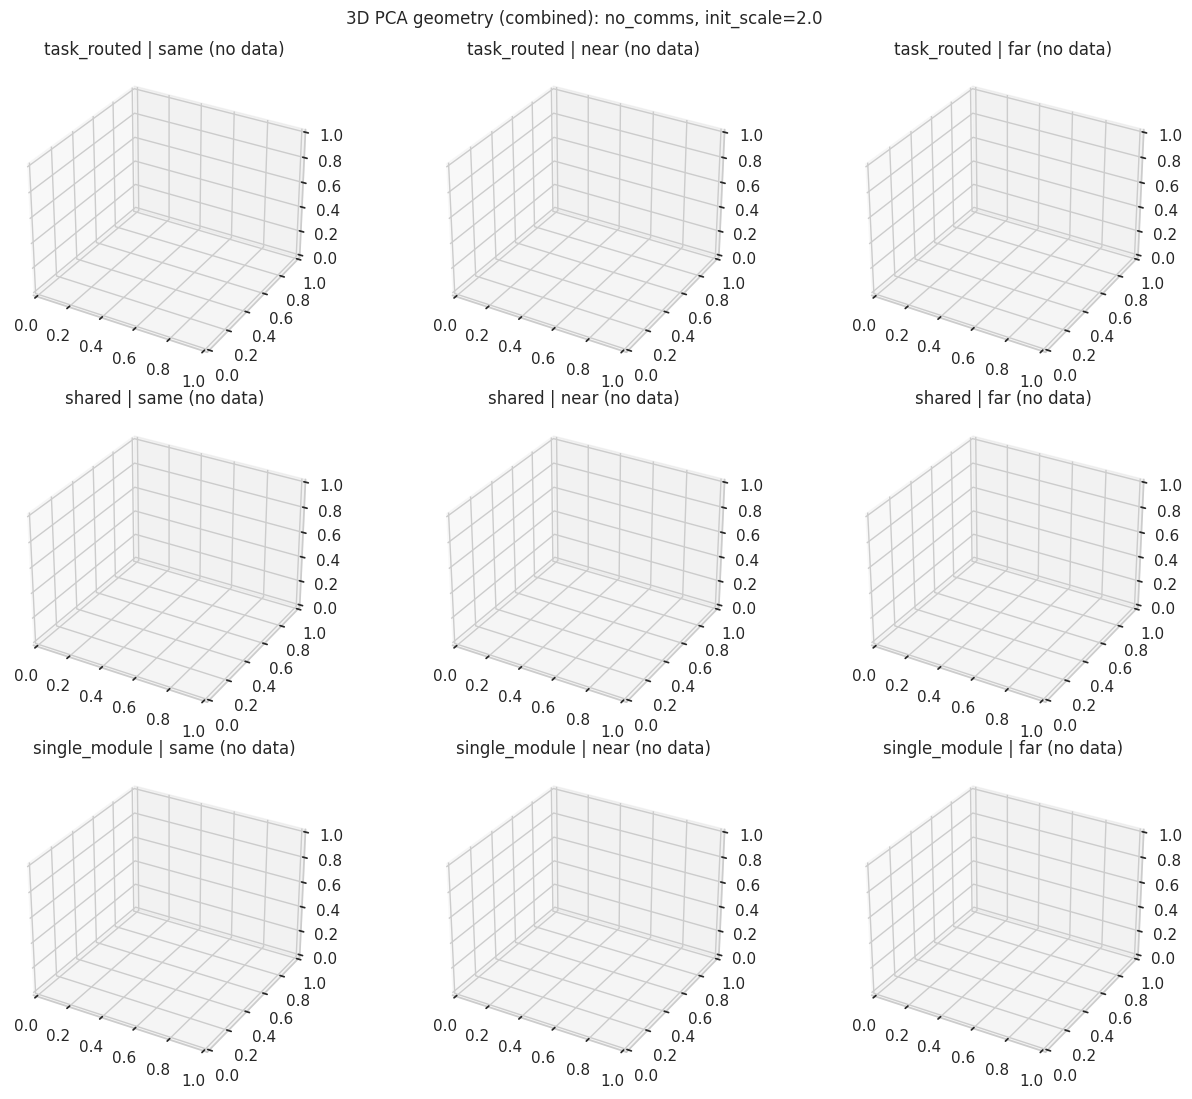

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from a1b2.utils.figure_utils import plot_split_stim_postA_postB_postA2_3d


def plot_geometry_grid_3d_by_init(init_scale: float, n_stim_plot: int = 12):
    arch_map = {
        "task_routed": all_task,
        "shared": all_shared,
        "single_module": all_single,
    }
    conds = SIMILARITY_ORDER

    fig = plt.figure(figsize=(13, 12))
    fig.suptitle(f"3D PCA geometry (combined): no_comms, init_scale={init_scale}", fontsize=12)

    legend_handles = None

    for i, arch in enumerate(ROUTING_HUE_ORDER):
        rid, bundle = _get_arch_bundle(arch_map.get(arch, {}), init_scale)
        for j, cond in enumerate(conds):
            ax = fig.add_subplot(3, 3, i * 3 + j + 1, projection="3d")
            if bundle is None:
                ax.set_title(f"{arch} | {cond} (no data)")
                continue
            ann_data = bundle["data"]
            entry = _first_entry_for_condition(ann_data, cond)
            if entry is None:
                ax.set_title(f"{arch} | {cond} (no data)")
                continue
            raw_A = entry.get("hiddens_post_phase_0")
            raw_B = entry.get("hiddens_post_phase_1")
            raw_A2 = entry.get("hiddens_post_phase_2")
            if raw_A is None or raw_B is None or raw_A2 is None:
                ax.set_title(f"{arch} | {cond} (insufficient)")
                continue

            h_A = np.asarray(raw_A)
            h_B = np.asarray(raw_B)
            h_A2 = np.asarray(raw_A2)
            if h_A.ndim != 2 or h_B.ndim != 2 or h_A2.ndim != 2:
                ax.set_title(f"{arch} | {cond} (insufficient)")
                continue
            if min(h_A.shape[0], h_B.shape[0], h_A2.shape[0]) < n_stim_plot:
                ax.set_title(f"{arch} | {cond} (insufficient)")
                continue

            h_A = h_A[:n_stim_plot]
            h_B = h_B[:n_stim_plot]
            h_A2 = h_A2[:n_stim_plot]
            _, X3_A, X3_B, X3_A2 = prepare_pca_shared_three_phase(h_A, h_B, h_A2, n_components=3)

            with_leg = legend_handles is None
            h = plot_split_stim_postA_postB_postA2_3d(ax, X3_A, X3_B, X3_A2, labels_for_legend=with_leg)
            if legend_handles is None and h:
                legend_handles = h

            ax.set_title(f"{arch} | {cond}\nrun={rid}")
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
            ax.set_zlabel("PC3")

    if legend_handles:
        fig.legend(
            legend_handles,
            [ln.get_label() for ln in legend_handles],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=False,
            fontsize=8,
        )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


for init_scale in init_order:
    plot_geometry_grid_3d_by_init(float(init_scale), n_stim_plot=12)
